In [2]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [7]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)   # Input -> 256 neurons
        self.fc2 = nn.Linear(256, 128)       # Hidden layer
        self.fc3 = nn.Linear(128, 10)        # Output layer (10 classes)
        self.relu = nn.ReLU()                # Activation function
        self.dropout = nn.Dropout(0.2)       # Dropout to prevent overfitting

    # Forward method defines how data flows through the network
    def forward(self, x):
        x = x.view(-1, 28 * 28)       # Flatten 28x28 image to 784
        x = self.relu(self.fc1(x))    # First layer + ReLU
        x = self.dropout(x)           # Apply dropout
        x = self.relu(self.fc2(x))    # Second layer + ReLU
        x = self.fc3(x)               # Output layer (logits)
        return x


In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))    # Normalize pixels to [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)


In [10]:
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)                  # Forward pass
        loss = criterion(output, target)      # Compute loss
        loss.backward()                       # Backpropagation
        optimizer.step()                      # Update weights

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


Epoch 1/10, Loss: 0.4399
Epoch 2/10, Loss: 0.1855
Epoch 3/10, Loss: 0.1438
Epoch 4/10, Loss: 0.1182
Epoch 5/10, Loss: 0.1007
Epoch 6/10, Loss: 0.0919
Epoch 7/10, Loss: 0.0838
Epoch 8/10, Loss: 0.0719
Epoch 9/10, Loss: 0.0701
Epoch 10/10, Loss: 0.0618


In [11]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)   # Get predicted class
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy = 100 * correct / total
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")



Final Test Accuracy: 98.16%


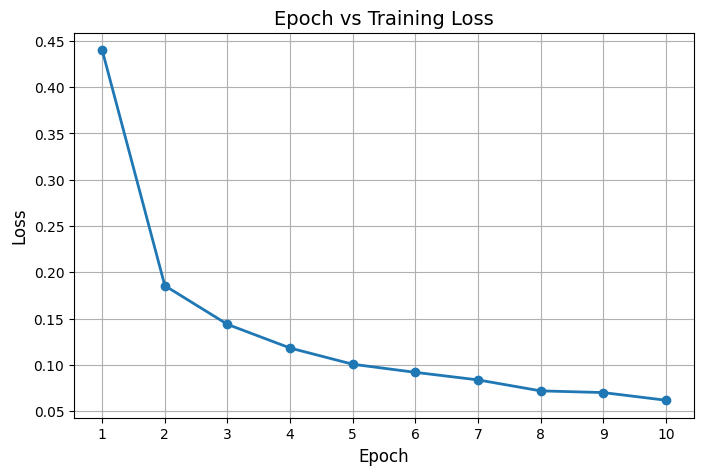

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Epoch vs Training Loss", fontsize=14)
plt.grid(True)
plt.xticks(range(1, num_epochs+1))
plt.show()
